## UTILIZANDO APIs REST

<p>Usando a <a href=https://pypi.org/project/nba_api/>API da NBA</a> para determinar o desempenho do Golden State Warriors contra o Toronto Raptors. Vamos usar a API para identificar a diferença de pontos pela qual o Worriors venceu ou perdeu em cada jogo.</p>

In [ ]:
# Instalando as bibliotecas e a API
!pip install -r requirements.txt
!pip install nba_api

In [29]:
# Importanto as bibliotecas que serão utilizadas.
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguegamefinder
import matplotlib.pyplot as plt
import numpy as np
import requests
import pandas as pd

<p>A função one_dict() irá receber uma lista de dicionários, cada um representando os dados de uma equipe, e os combinará em um único dicionário, no qual cada chave irá conter uma lista de todos os valores correspondentes.</p>

In [30]:
# definindo a função
def one_dict(list_dict):
    keys=list_dict[0].keys()             # as chaves são extraídas do primeiro dicionário da lista
    out_dict={key:[] for key in keys}    # cria um diacionário de saída onde cada chave tem uma lista vazia
    for dict_ in list_dict:              # para cada dionário na lista, itera sobre seus pares chave-valor e adiciona o valor á lista correspondente em out_dict
        for key, value in dict_.items():
            out_dict[key].append(value)
    return out_dict                      # retorna o diconário resultante

# O método get_teams() retorna uma lista de dicionários
nba_teams = teams.get_teams()

# Key é identificador único em um dicionário, que neste é o id. Vamos ver os três primeiros elementos da lista:
nba_teams[0:3]

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970}]

<p>Para facilitar, vamos converter o dicionário em uma tabela. Primeiro, usando a função 'one_dict()' para criar um dicionário. Em seguida, vamos converter o dicionário em um dataframe, em que cada linha contém as informações de um time diferente.</p>

In [31]:
dict_nba_team=one_dict(nba_teams)
df_teams=pd.DataFrame(dict_nba_team)
df_teams.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


In [32]:
# Usaremos o apelido da equipe, 'nickname', para encontrar o id do Golden State Warriors
df_warriors=df_teams[df_teams['nickname']=='Warriors']
print(df_warriors)


           id              full_name abbreviation  nickname           city  \
7  1610612744  Golden State Warriors          GSW  Warriors  San Francisco   

        state  year_founded  
7  California          1946  


In [33]:
# extraindo o primeiro valor da coluna 'id' e armazenando em uma variável
id_warriors=df_warriors[['id']].values[0][0]
# agora temos um inteiro que pode ser usado para solicitarmos informações dos Warriors
id_warriors

np.int64(1610612744)

In [34]:
# A função 'LeagueGameFinder' fará uma requisição à API.
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=id_warriors) # as informações solicitadas serão atruidas à variável gamefinder

<p>O objeto 'game_finder' possui um método 'get_data_frames()', que retorna um dataframe. Podemos ver que ele contém informações sobre todos os jogos disputados pelos Warriors. A coluna PLUS_MINUS contém informações sobre o placar, se o valor for negativo, os Warriors perderam por essa diferença de pontos, se o valor for positivo, os Warriors venceram por essa diferença de pontos. A coluna MATCHUP indica o time contra o qual os Warriors jogaram. GSW significa Golden State Warriors e TOR significa Toronto Raptors. O símbolo 'vs' indica que foi um jogo em casa, e o símbolo '@' significa um jogo fora de casa.</p>

In [35]:
games = gamefinder.get_data_frames()[0]
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22025,1610612744,GSW,Golden State Warriors,0022501154,2026-04-07,GSW vs. SAC,W,241,110,...,0.792,13.0,26.0,39.0,27,10,5,17,15,5.0
1,22025,1610612744,GSW,Golden State Warriors,0022501142,2026-04-05,GSW vs. HOU,L,241,116,...,0.900,6.0,25.0,31.0,34,7,3,10,19,-1.0
2,22025,1610612744,GSW,Golden State Warriors,0022501117,2026-04-02,GSW vs. CLE,L,240,111,...,0.850,12.0,34.0,46.0,25,11,5,12,20,-7.0
3,22025,1610612744,GSW,Golden State Warriors,0022501113,2026-04-01,GSW vs. SAS,L,240,113,...,0.833,7.0,32.0,39.0,29,6,3,13,26,-14.0
4,22025,1610612744,GSW,Golden State Warriors,0022501090,2026-03-29,GSW @ DEN,L,241,93,...,0.818,9.0,32.0,41.0,29,9,2,13,18,-23.0


In [36]:
games['GAME_DATE'].dtype

<StringDtype(storage='python', na_value=nan)>

In [37]:
# Criando dois dataframes contendo sometente partidas contra os Raptors, um para partidas fora e outro para partidas em casa.
games_home=games[games['MATCHUP']=='GSW vs. TOR']
games_away=games[games['MATCHUP']=='GSW @ TOR']

In [38]:
games_home['PLUS_MINUS'].mean()

np.float64(2.40625)

In [39]:
games_away['PLUS_MINUS'].mean()

np.float64(-2.3125)

In [40]:
games_away['GAME_DATE'] = pd.to_datetime(games_away['GAME_DATE'])
games_home['GAME_DATE'] = pd.to_datetime(games_home['GAME_DATE'])

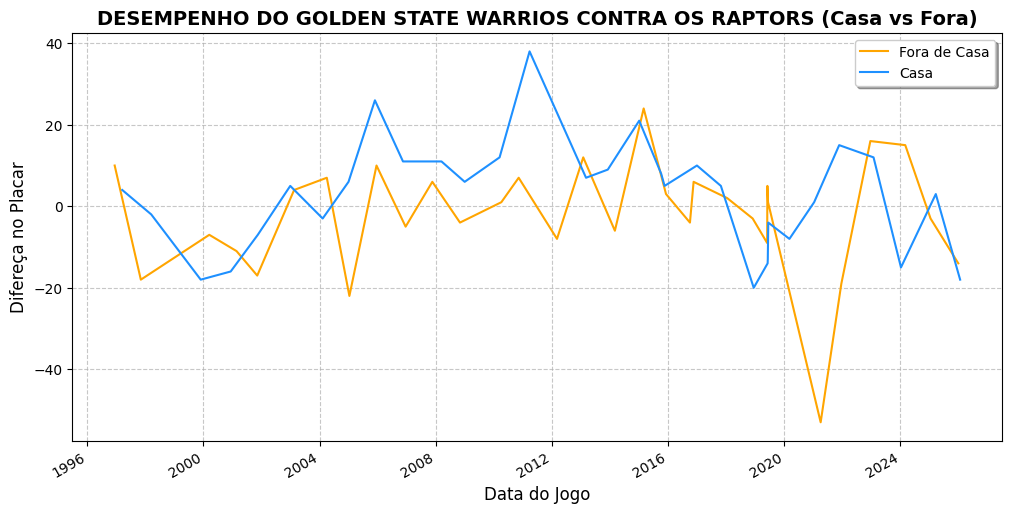

In [41]:
fig, ax = plt.subplots(figsize=(12, 6)) 
games_away.plot(x='GAME_DATE', y='PLUS_MINUS', ax=ax, color='orange', linewidth=1.5, label='Fora')
games_home.plot(x='GAME_DATE', y='PLUS_MINUS', ax=ax, color='dodgerblue', linewidth=1.5, label='Casa')
ax.grid(True, linestyle='--', alpha=0.7, axis='both')
ax.set_title('DESEMPENHO DO GOLDEN STATE WARRIOS CONTRA OS RAPTORS (Casa vs Fora)', fontsize=14, fontweight='bold')
ax.set_xlabel('Data do Jogo', fontsize=12)
ax.set_ylabel('Difereça no Placar', fontsize=12)
ax.legend(['Fora de Casa', 'Casa'], loc='best', frameon=True, fancybox=True, shadow=True)

Home average points:  106.8076923076923
Away average points:  102.96428571428571
